### Fake News Classification

##### Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
!pip install xgboost

In [5]:
!pip install lightgbm

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

#### EDA

In [7]:
dataset_path = 'WELFake_Dataset.csv'
df = pd.read_csv(dataset_path)
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Total rows: 72134
Total columns: 4


In [8]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [9]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [11]:
df.describe()

,Unnamed: 0,label
count,72134.000000,72134.000000
mean,36066.500000,0.514404
std,20823.436496,0.499796
min,0.000000,0.000000
25%,18033.250000,0.000000
50%,36066.500000,1.000000
75%,54099.750000,1.000000
max,72133.000000,1.000000


In [12]:
df.shape

(72134, 4)

#### Data Processing


##### Chek for missing(null) values in each column

In [13]:
df.isnull().sum()

Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

In [14]:
## Drop Nan Values
df=df.dropna()

In [15]:
df.isnull().sum()

Unnamed: 0    0
title         0
text          0
label         0
dtype: int64

In [16]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
5,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1


In [17]:
df = df.drop(columns= ["Unnamed: 0"])

In [18]:
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1


##### check for duplicate rows in the dataset

In [19]:
df.duplicated().sum()

8416

In [20]:
df.drop_duplicates(inplace= True)

In [21]:
df.duplicated().sum()

0

In [22]:
X=df.drop('label',axis=1)  ## Independent Features

In [23]:
y=df['label']   ## Dependent features

In [24]:
X.shape

(63121, 2)

In [25]:
y.shape

(63121,)

##### Import Lidraries for text preprocessing

In [26]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer   ##stemming purpose

In [27]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [28]:
stopwords = set(stopwords.words("english"))

In [29]:
ps = PorterStemmer()
def cleaning(text):
    text = re.sub(r"<.*?>", "", text)                        #Also Remove HTML tags
    text = text.lower()                                      # Lowercase
    text = re.sub(r'_+', ' ', text)
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)      # Remove URLs
    text = re.sub(r'\d+', '', text)                          # Remove digits
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)              # Remove all single characters from text
    text = re.sub(r"[^\w\s]", "", text)                      # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()                 # Remove extra whitespace
    words = text.split()                                     # Tokenize
    words = [ps.stem(word) for word in words if word not in stopwords]  # Remove stop words
    words = [re.sub(r'(.)\1{2,}', r'\1\1', word) for word in words]  # Limit repeated letters to 2 max

    clean_text = ' '.join(words)                                # Join back into one string
    clean_text = re.sub(r'\b(\w+)( \1\b)+', r'\1', clean_text)  # Remove repeated consecutive words

    return clean_text

In [30]:
for col in ['title', 'text']:
    df[col + "_clean"] = df[col].apply(cleaning)

In [31]:
df.head()

,title,text,label,title_clean,text_clean
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforc high alert follow threat cop white ...,comment expect barack obama member fyf fukyofl...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbeliev obama attorney gener say charlott rio...,demonstr gather last night exercis constitut p...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobbi jindal rais hindu use stori christian co...,dozen polit activ pastor came privat dinner fr...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan russia unv imag terrifi new supernuk wes...,rs sarmat missil dub satan replac ss fli mile ...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,time christian group sue amazon splc design ha...,say one time someon su southern poverti law ce...


In [32]:
df.loc[420:430]

,title,text,label,title_clean,text_clean
420,TRUMP SUGGESTS People Should Sue ABC NEWS Afte...,President Trump is not giving ABC News a pass ...,1,trump suggest peopl sue abc news massiv stock ...,presid trump give abc news pass fake news stor...
421,HEATED! TUCKER CARLSON Totally Shuts Down Radi...,https://www.youtube.com/watch?v=RRPSCqkAJgk,1,heat tucker carlson total shut radic liber fox...,
422,"'God bless you', Netanyahu tells Guatemalan pr...",JERUSALEM/GUATEMALA CITY (Reuters) - Israeli P...,0,god bless netanyahu tell guatemalan presid jer...,jerusalemguatemala citi reuter isra prime mini...
423,US Government and the Clinton female: Come to ...,America is going nuts. Suggestions stupidly ...,1,us govern clinton femal come psychiatrist couch,america go nut suggest stupidli abound russian...
424,Kansai Electric to scrap two reactors in lates...,TOKYO (Reuters) - Kansai Electric Power Co sai...,0,kansai electr scrap two reactor latest blow ja...,tokyo reuter kansai electr power co said frida...
425,"Suburban G.O.P. Voters Sour on Party, Raising ...","ALPHARETTA, Ga. — A gray mood has settled o...",0,suburban gop voter sour parti rais republican ...,alpharetta ga gray mood settl voter countri re...
426,Ex-Cuomo Aides Charged in Federal Corruption I...,Federal corruption charges were announced on T...,0,excuomo aid charg feder corrupt inquiri new yo...,feder corrupt charg announc thursday two forme...
427,The delay over Loretta Lynch’s confirmation is...,Let’s get a few things straight about the dela...,0,delay loretta lynch confirm isnt bia,let get thing straight delay confirm loretta l...
428,BREAKING: GUN STORE OWNER Claims He DID Report...,"If you see something say something and maybe, ...",1,break gun store owner claim report florida ter...,see someth say someth mayb fbi busi spend time...
429,"Mooch Changes His Tune, Says Reporter ‘Absolu...",So here s a funny hypothetical: You re a White...,1,mooch chang tune say report absolut record wit...,funni hypothet white hous commun director sett...


In [33]:
df["combined"] = df["title_clean"].astype(str) + " " + df["text_clean"].astype(str)
df.head()

,title,text,label,title_clean,text_clean,combined
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforc high alert follow threat cop white ...,comment expect barack obama member fyf fukyofl...,law enforc high alert follow threat cop white ...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbeliev obama attorney gener say charlott rio...,demonstr gather last night exercis constitut p...,unbeliev obama attorney gener say charlott rio...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobbi jindal rais hindu use stori christian co...,dozen polit activ pastor came privat dinner fr...,bobbi jindal rais hindu use stori christian co...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan russia unv imag terrifi new supernuk wes...,rs sarmat missil dub satan replac ss fli mile ...,satan russia unv imag terrifi new supernuk wes...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,time christian group sue amazon splc design ha...,say one time someon su southern poverti law ce...,time christian group sue amazon splc design ha...


#### Train Test Split

In [34]:
X = df["combined"]
y = df["label"]

##### Split the dataset into training and testing sets

In [35]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.33, random_state=42)


##### Convert text data into numerical feactures using TF-IDF

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_df=0.90, min_df = 2, max_features=5000, stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

#### Model training

##### 1. LogisticRegression Model

In [37]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=100)

# Train the model
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression()

##### Performance Metrics And Accuracy

In [38]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [39]:
print("F1_Score: ",f1_score(y_test,y_pred_lr))
print("Accuracy_Score: ", accuracy_score(y_test,y_pred_lr))
print("Confusion_Matrix: \n ", confusion_matrix(y_test, y_pred_lr))

F1_Score:  0.9339858503111867
Accuracy_Score:  0.9404224675948152
Confusion_Matrix: 
  [[10810   602]
 [  639  8779]]


##### 2. RadomForestClassifier

In [40]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_tfidf, y_train)

RandomForestClassifier(random_state=42)

##### Performance Metrics And Accuracy

In [41]:
y_pred_rf  = lr_model.predict(X_test_tfidf)

In [42]:
print("F1_Score: ",f1_score(y_test, y_pred_rf))
print("Accuracy_Score: ", accuracy_score(y_test, y_pred_rf))
print("Confusion_Matrix: \n ", confusion_matrix(y_test, y_pred_rf))

F1_Score:  0.9339858503111867
Accuracy_Score:  0.9404224675948152
Confusion_Matrix: 
  [[10810   602]
 [  639  8779]]


##### 3. XGBClassifiier

In [43]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier()

xgb_model.fit(X_train_tfidf, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

##### Performance Metrics And Accuracy

In [44]:
y_pred_xgb = xgb_model.predict(X_test_tfidf)

In [45]:
print("F1_Score: ",f1_score(y_test, y_pred_xgb))
print("Accuracy_Score: ", accuracy_score(y_test, y_pred_xgb))
print("Confusion_Matrix: \n ", confusion_matrix(y_test, y_pred_xgb))

F1_Score:  0.950724942214751
Accuracy_Score:  0.9549687950072011
Confusion_Matrix: 
  [[10843   569]
 [  369  9049]]


##### 4. LGBMClassifier

In [46]:
from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier()

lgbm_model.fit(X_train_tfidf, y_train)

[LightGBM] [Info] Number of positive: 18912, number of negative: 23379
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.593673 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 865729
[LightGBM] [Info] Number of data points in the train set: 42291, number of used features: 5000
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.447187 -> initscore=-0.212042
[LightGBM] [Info] Start training from score -0.212042


LGBMClassifier()

##### Perfomance Metrics And Accuracy

In [47]:
y_pred_lgbm = lgbm_model.predict(X_test_tfidf)

In [48]:
print("F1_Score: ",f1_score(y_test, y_pred_lgbm))
print("Accuracy_Score: ", accuracy_score(y_test, y_pred_lgbm))
print("Confusion_Matrix: \n ", confusion_matrix(y_test, y_pred_lgbm))

F1_Score:  0.9525614700152688
Accuracy_Score:  0.956745079212674
Confusion_Matrix: 
  [[10883   529]
 [  372  9046]]


##### Caculate F1 Score for each model

In [49]:
from sklearn.metrics import f1_score

f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
f1_lgbm = f1_score(y_test, y_pred_lgbm, average='weighted')

print("Logistic Regression F1:", f1_lr)
print("Random Forest F1:", f1_rf)
print("XGBoost F1:", f1_xgb)
print("LightGBM F1:", f1_lgbm)

Logistic Regression F1: 0.9404120500785431
Random Forest F1: 0.9404120500785431
XGBoost F1: 0.955006311386201
LightGBM F1: 0.956774056432597


In [ ]:
# (keras install removed - this notebook now uses PyTorch)
!pip install torch transformers -q

In [51]:
!pip install seaborn


In [ ]:
# (tensorflow install removed - this notebook now uses PyTorch)

Bert

In [ ]:
# PyTorch + transformers for the BERT section (CPU build of torch is default on Windows pip)
!pip install torch transformers -q

In [ ]:
import torch
import transformers

print('PyTorch     :', torch.__version__)
print('Transformers:', transformers.__version__)
print('Python      :', __import__('sys').version)
print('CUDA available:', torch.cuda.is_available(), '(CPU mode used below)')

In [ ]:
import transformers
print(transformers.__version__)

In [ ]:
# (tf-cpu install no longer needed - using PyTorch)

In [58]:
!pip install "transformers==4.46.3" "huggingface_hub==0.26.5" "tokenizers<0.21" -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.37.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.26.5 which is incompatible.


In [8]:
!pip install tf-keras -q


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import transformers
from transformers import AutoTokenizer, AutoModel

SEED = 10
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cpu')
print('Using device:', DEVICE)

In [ ]:
df = pd.read_csv('WELFake_Dataset.csv')
df.dropna(subset=['text', 'title'], inplace=True)
df['text'] = df['title'] + ' ' + df['text']

X = df['text']
y = df['label']

# Train/test split used by the PyTorch BERT pipeline below.
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=SEED, stratify=y.values,
)
print(f'Train: {len(X_train):,}  Test: {len(X_test):,}')

### 1. EDA

In [3]:
df['num_words'] = df['text'].apply(lambda x: len(x.split()))

C:\Users\Admin\AppData\Local\Temp\ipykernel_29308\2373055195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['label'], palette = 'Set1', alpha = 0.8)


Text(0.5, 1.0, 'Distribution of Fake - 0 /Real - 1 News')

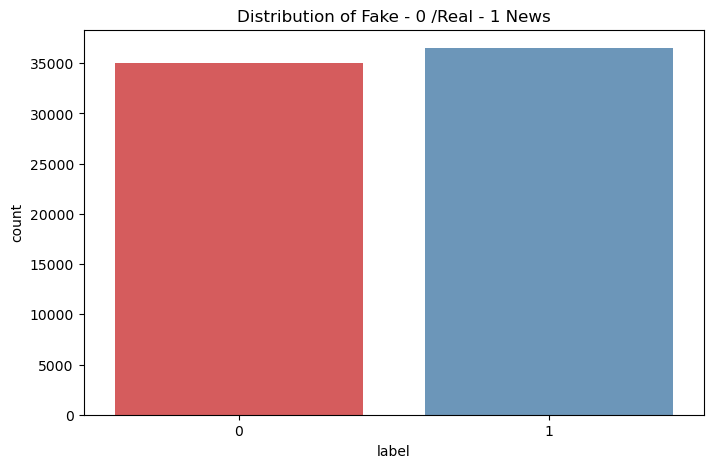

In [4]:
plt.figure(figsize = (8,5))
sns.countplot(x = df['label'], palette = 'Set1', alpha = 0.8)
plt.title('Distribution of Fake - 0 /Real - 1 News')

C:\Users\Admin\AppData\Local\Temp\ipykernel_29308\4258687771.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['num_words'], bins = range(1, 3000, 50), palette = 'Set1', alpha = 0.8)


Text(0.5, 1.0, 'Distribution of the News Words count')

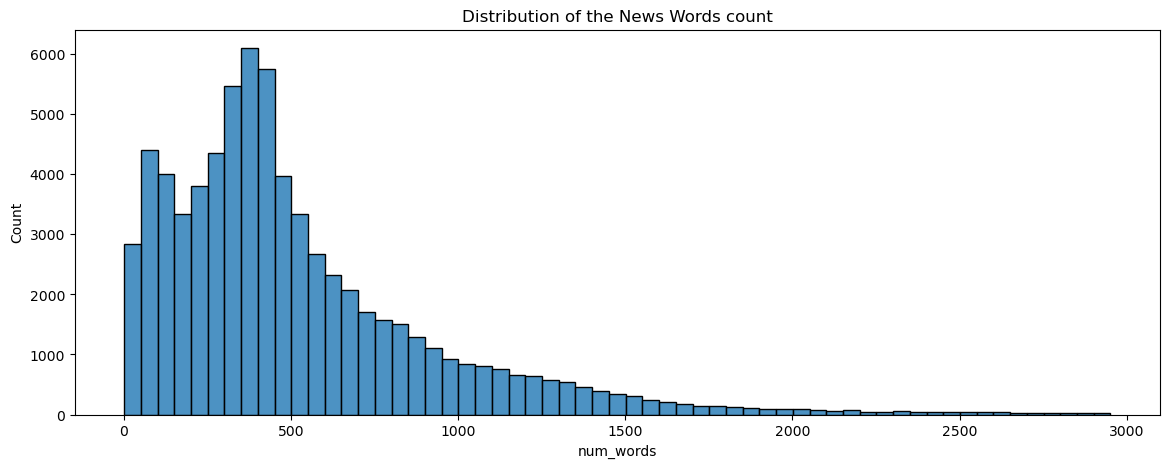

In [5]:
plt.figure(figsize = (14,5))
sns.histplot(df['num_words'], bins = range(1, 3000, 50), palette = 'Set1', alpha = 0.8)
plt.title('Distribution of the News Words count')

#### 2. Define Model

In [ ]:
# Hyperparameters for the BERT pipeline.
# DistilBERT is used in place of bert-base-uncased because it is roughly 2x faster
# on CPU with comparable accuracy on this task. Switch MODEL_NAME to
# 'bert-base-uncased' if you want the original model and have the CPU budget.
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128
BATCH_SIZE = 16     # CPU-friendly
EPOCHS     = 3
LR         = 1e-3   # for the small head (the encoder is frozen)

def get_tokens(texts, tokenizer, max_len=MAX_LEN):
    """Tokenize a sequence of texts into PyTorch tensors."""
    enc = tokenizer(
        list(texts),
        add_special_tokens=True,
        max_length=max_len,
        truncation=True,
        padding='max_length',
        return_tensors='pt',
        return_attention_mask=True,
        return_token_type_ids=False,
    )
    return enc

class BertClassifier(nn.Module):
    """Frozen transformer encoder + lightweight classification head.

    The encoder's [CLS] vector (first token of last hidden state) is passed
    through Dropout -> Linear(768, 64) -> ReLU -> Dropout -> Linear(64, 1).
    Output is a single logit (use BCEWithLogitsLoss).
    """
    def __init__(self, model_name=MODEL_NAME, dropout=0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        for p in self.encoder.parameters():
            p.requires_grad = False
        hidden = self.encoder.config.hidden_size
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.head(cls).squeeze(-1)

def make_loader(input_ids, attention_mask, labels=None, batch_size=BATCH_SIZE, shuffle=False):
    if labels is None:
        ds = TensorDataset(input_ids, attention_mask)
    else:
        ds = TensorDataset(input_ids, attention_mask, torch.tensor(labels, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

In [ ]:
# Load tokenizer and model. The encoder is frozen inside BertClassifier;
# only the small head will be trained.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = BertClassifier(MODEL_NAME).to(DEVICE)
model.encoder.train(False)  # encoder in inference mode

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable / total parameters: {trainable:,} / {total:,}')

In [ ]:
!pip install "transformers<5" -q


#### 3. Train and evaluate

#### We will use a validation split of 20% during the training

In [ ]:
# Tokenize once, then train the head with mini-batch SGD.
# An 80/20 train/validation split is used inside X_train for early stopping.
from sklearn.model_selection import train_test_split as _tts
X_tr_raw, X_val_raw, y_tr, y_val = _tts(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train,
)

print('Tokenizing splits...')
tok_tr  = get_tokens(X_tr_raw,  tokenizer)
tok_val = get_tokens(X_val_raw, tokenizer)
tok_te  = get_tokens(X_test,    tokenizer)

train_loader = make_loader(tok_tr['input_ids'],  tok_tr['attention_mask'],  y_tr,  shuffle=True)
val_loader   = make_loader(tok_val['input_ids'], tok_val['attention_mask'], y_val, shuffle=False)

optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=LR,
)
loss_fn = nn.BCEWithLogitsLoss()

def epoch_metrics(loader):
    model.head.train(False)
    total_loss = total_correct = total_n = 0
    with torch.no_grad():
        for batch in loader:
            input_ids, attn_mask, yb = batch
            input_ids = input_ids.to(DEVICE); attn_mask = attn_mask.to(DEVICE); yb = yb.to(DEVICE)
            logits = model(input_ids, attn_mask)
            total_loss    += loss_fn(logits, yb).item() * yb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            total_correct += (preds == yb).sum().item()
            total_n       += yb.size(0)
    return total_loss / total_n, total_correct / total_n

history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
best_val_acc = -1.0
best_state   = None
patience     = 3
stale        = 0

for epoch in range(1, EPOCHS + 1):
    model.head.train(True)
    for batch in train_loader:
        input_ids, attn_mask, yb = batch
        input_ids = input_ids.to(DEVICE); attn_mask = attn_mask.to(DEVICE); yb = yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(input_ids, attn_mask)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
    tr_loss,  tr_acc  = epoch_metrics(train_loader)
    val_loss, val_acc = epoch_metrics(val_loader)
    history['loss'].append(tr_loss);   history['val_loss'].append(val_loss)
    history['accuracy'].append(tr_acc); history['val_accuracy'].append(val_acc)
    print(f'Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} '
          f'| val loss {val_loss:.4f} acc {val_acc:.4f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.clone() for k, v in model.head.state_dict().items()}
        stale = 0
    else:
        stale += 1
        if stale >= patience:
            print(f'Early stopping at epoch {epoch} (best val acc {best_val_acc:.4f}).')
            break

if best_state is not None:
    model.head.load_state_dict(best_state)

In [ ]:
def plot_graphs(history, metric):
    plt.plot(history[metric])
    plt.plot(history['val_' + metric], '')
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.legend([metric, 'val_' + metric])

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.tight_layout()
plt.show()

#### 3.2 Evaluate the model

#### For final evaluation we use the separate test set

In [ ]:
# Predict the test set labels.
test_loader = make_loader(tok_te['input_ids'], tok_te['attention_mask'], batch_size=BATCH_SIZE, shuffle=False)

model.head.train(False)
probs_list = []
with torch.no_grad():
    for input_ids, attn_mask in test_loader:
        input_ids = input_ids.to(DEVICE); attn_mask = attn_mask.to(DEVICE)
        logits = model(input_ids, attn_mask)
        probs_list.append(torch.sigmoid(logits).cpu().numpy())

yhat_probs = np.concatenate(probs_list)
yhat = (yhat_probs >= 0.5).astype(int)

In [ ]:
## print classification report
print(classification_report(y_test,yhat))

NameError: name 'yhat' is not defined

In [ ]:
#plot the confusion matrix
plt.figure(figsize = (8,6))

sns.heatmap(confusion_matrix(y_test,yhat), annot=True,
            fmt='', cmap='Blues')

plt.xlabel('Predicted Labels')
plt.ylabel('Real Labels')

NameError: name 'yhat' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
# Save the trained head weights. The frozen encoder is reloaded from the Hub at inference time,
# so we don't need to persist its 66M parameters.
torch.save(model.head.state_dict(), 'fake_news_bert_head.pt')
tokenizer.save_pretrained('fake_news_bert_tokenizer')
print('Saved head weights and tokenizer.')